### Error Analysis EmoDB

In [1]:
import pandas as pd

pred_files = {
    "predictions_distilhubert" : r"C:\path\to\test_predictions_distilhubert.csv",  
    "predictions_hubert_b": r"C:\path\to\test_predictions_hubertxl.csv", 
    "predictions_wav2vec_b" : r"C:\path\to\test_predictions_wav2vec_b.csv", 
    "predictions_wav2vec_l" : r"C:\path\to\test_predictions_wav2vec_l.csv", 
    "predictions_wavlm_b" : r"C:\path\to\test_predictions_wavlm_b.csv",
    "predictions_wavlm_l" : r"C:\path\to\test_predictions_wavlm_l.csv" }

female_speakers = [8,9,13,14,16]
male_speakers= [3,10,11,12,15]


def get_gender(speaker_id): 
    if speaker_id in female_speakers: 
        return "female"
    elif speaker_id in male_speakers:
        return "male"
    else:
        return "unclear gender"

def analysed_wrong_preds(csv_path): 
    df = pd.read_csv(csv_path, sep= None, engine= "python")
    if df["correct"].dtype == object: 
        df["correct"] = df["correct"].astype(str).str.strip().str.lower() == "true"

    df["speaker_id"] = df["audio_file"].str[:2].astype(int)
    df["gender"] = df["speaker_id"].apply(get_gender)
    total_by_gender = df["gender"].value_counts()

    wrong_df = df[df["correct"] == False]
    wrong_by_gender = wrong_df["gender"].value_counts()

    male_total = total_by_gender.get("male", 0)
    female_total = total_by_gender.get("female", 0)
    male_wrong = wrong_by_gender.get("male", 0)
    female_wrong = wrong_by_gender.get("female", 0)


    return{
        "total_wrong" : len(wrong_df),
        "male_total" : male_total,
        "male_wrong": male_wrong,
        "female_total": female_total,
        "female_wrong": female_wrong,
        "male_error_rate_perc": round(male_wrong/male_total * 100, 2) if male_total else None,
        "female_error_rate_perc": round(female_wrong/female_total * 100, 2) if female_total else None
    }

#### Getting a basic idea about the test set size and how many samples per emotion it includes 

In [2]:
test_sample_path = pred_files["predictions_distilhubert"]
df = pd.read_csv(test_sample_path, sep= None, engine= "python")

emo_counts = df["ground_truth"].value_counts().sort_index()
print("Number of Emotion Samples in Test Set")
print(emo_counts)
print(f"Total number of samples {len(df)}")

Number of Emotion Samples in Test Set
ground_truth
anger        19
boredom      12
disgust       7
fear         11
happiness    11
neutral      12
sadness       9
Name: count, dtype: int64
Total number of samples 81


### Checking if the gender imbalance of the EmoDB dataset impacted overall model misclassifications

In [5]:
results = {}
for model_name, path in pred_files.items():
    results[model_name] = analysed_wrong_preds(path)

summary_df = pd.DataFrame(results).T
print(summary_df)

                          total_wrong  male_total  male_wrong  female_total  \
predictions_distilhubert         14.0        35.0         6.0          46.0   
predictions_hubert_b              5.0        35.0         2.0          46.0   
predictions_hubert_xl             7.0        35.0         3.0          46.0   
predictions_wav2vec_b             5.0        35.0         2.0          46.0   
predictions_wav2vec_l            13.0        35.0         4.0          46.0   
predictions_wavlm_b               3.0        35.0         0.0          46.0   
predictions_wavlm_l               1.0        35.0         1.0          46.0   

                          female_wrong  male_error_rate_perc  \
predictions_distilhubert           8.0                 17.14   
predictions_hubert_b               3.0                  5.71   
predictions_hubert_xl              4.0                  8.57   
predictions_wav2vec_b              3.0                  5.71   
predictions_wav2vec_l              9.0         

>> Findings:
>> For most of the models, the error rate is almost identical between male and female audio files of the test set or the difference is negligible (eg wav2vec base). Except for one model, namely Wav2Vec Large (19.57% - 11.43% = 8.14% difference in error rate), however, maybe it is not female files in general which are not detected here but one or two speakers

In [2]:
def print_false_female_files(csv_path):
    df = pd.read_csv(csv_path, sep= None, engine= "python")
    if df["correct"].dtype == object: 
        df["correct"] = df["correct"].astype(str).str.strip().str.lower() == "true"

    df["speaker_id"] = df["audio_file"].str[:2].astype(int)
    df["gender"] = df["speaker_id"].apply(get_gender)
    total_by_gender = df["gender"].value_counts()

    false_female_df = df[(df["correct"] == False) & (df["gender"] == "female")]
    print(f"{len(false_female_df)} false female files")

    grouped = false_female_df.groupby("speaker_id")["audio_file"].apply(list)

    for speaker_id, files in grouped.items():
        print(f"Speaker {speaker_id} ({len(files)} files): {files}")

    return false_female_df

for model_name, path in pred_files.items():
    print(f"\n *** {model_name} ***")
    print_false_female_files(path)


 *** predictions_distilhubert ***
8 false female files
Speaker 8 (3 files): ['08a01Fd.wav', '08a04Nc.wav', '08a05Lc.wav']
Speaker 9 (2 files): ['09a07Wd.wav', '09a01Fa.wav']
Speaker 14 (1 files): ['14b09Fc.wav']
Speaker 16 (2 files): ['16b03Fd.wav', '16a05Ab.wav']

 *** predictions_hubert_b ***
3 false female files
Speaker 9 (1 files): ['09a01Fa.wav']
Speaker 14 (1 files): ['14b09Fc.wav']
Speaker 16 (1 files): ['16a01Wb.wav']

 *** predictions_hubert_xl ***
4 false female files
Speaker 9 (1 files): ['09a01Fa.wav']
Speaker 13 (1 files): ['13b09La.wav']
Speaker 14 (1 files): ['14b09Fc.wav']
Speaker 16 (1 files): ['16b03Fd.wav']

 *** predictions_wav2vec_b ***
3 false female files
Speaker 8 (1 files): ['08a01Fd.wav']
Speaker 9 (1 files): ['09a01Fa.wav']
Speaker 14 (1 files): ['14b09Fc.wav']

 *** predictions_wav2vec_l ***
9 false female files
Speaker 8 (2 files): ['08a01Fd.wav', '08a04Nc.wav']
Speaker 9 (2 files): ['09a02Ea.wav', '09a01Fa.wav']
Speaker 13 (1 files): ['13a07Na.wav']
Speak

>> Findings:
>> The dominating misclassified recordings of female speakers are of speaker 9 and 14 (they appear in all the misclassified female files in all the models); other than in wav2vec base, speaker 16 also appears in all the misclassified ones. 

In [21]:
def print_false_male_files(csv_path):
    df = pd.read_csv(csv_path, sep= None, engine= "python")
    if df["correct"].dtype == object: 
        df["correct"] = df["correct"].astype(str).str.strip().str.lower() == "true"

    df["speaker_id"] = df["audio_file"].str[:2].astype(int)
    df["gender"] = df["speaker_id"].apply(get_gender)
    total_by_gender = df["gender"].value_counts()

    false_male_df = df[(df["correct"] == False) & (df["gender"] == "male")]
    print(f"{len(false_male_df)} false male files")

    grouped = false_male_df.groupby("speaker_id")["audio_file"].apply(list)

    for speaker_id, files in grouped.items():
        print(f"Speaker {speaker_id} ({len(files)} files): {files}")

    return false_male_df

for model_name, path in pred_files.items():
    print(f"\n *** {model_name} ***")
    print_false_male_files(path)


 *** predictions_distilhubert ***
6 false male files
Speaker 3 (2 files): ['03a07Fa.wav', '03b02La.wav']
Speaker 11 (1 files): ['11b09Fd.wav']
Speaker 12 (1 files): ['12b03La.wav']
Speaker 15 (2 files): ['15b01Wc.wav', '15b02Lb.wav']

 *** predictions_hubert_b ***
2 false male files
Speaker 3 (1 files): ['03b02La.wav']
Speaker 12 (1 files): ['12a02Nb.wav']

 *** predictions_hubert_xl ***
3 false male files
Speaker 3 (2 files): ['03b02La.wav', '03b09La.wav']
Speaker 11 (1 files): ['11b09Fd.wav']

 *** predictions_wav2vec_b ***
2 false male files
Speaker 3 (1 files): ['03a07Fa.wav']
Speaker 12 (1 files): ['12b03La.wav']

 *** predictions_wav2vec_l ***
4 false male files
Speaker 3 (2 files): ['03b02Na.wav', '03b02La.wav']
Speaker 11 (1 files): ['11b09Fd.wav']
Speaker 15 (1 files): ['15b02Lb.wav']

 *** predictions_wavlm_b ***
0 false male files

 *** predictions_wavlm_l ***
1 false male files
Speaker 3 (1 files): ['03b02La.wav']


>> Findings:
>> Speaker 3 is clearly dominating the misclassified male files, with the same file always being misclassified. The same file of Speaker 11 is also misclassified by 3 models and for speaker 12 the same file is misclassified by two models

### Getting an idea of whether noise played a role in the misclassifications

In [22]:
from scipy.io import wavfile

def sound_noise_ratio(audio_data, sample_rate, snr_treshold= 20.0, frame_duration=0.02):  
    if len(audio_data.shape) > 1:   #making sure not only mono but also stereo can be handled
        audio_data = np.mean(audio_data, axis=1)

    audio_data = audio_data.astype(np.float64)
    frame_size= int(frame_duration*sample_rate)
    frame_number = len(audio_data) // frame_size

    sound_intensity_frame = [np.var(audio_data[i*frame_size : (i+1)*frame_size]) for i in range(frame_number)]
    sound_intensity_frame = np.array(sound_intensity_frame)

    noise_intensity = np.percentile(sound_intensity_frame, 15)
    speech_intensity = np.percentile(sound_intensity_frame, 50)

    if noise_intensity == 0: 
        noise_intensity = 1e-10  #to avoid zero devision

    #formula: SNR(dB) = 10*log10(signal power/noise power)
    snr_db = 10*np.log10(speech_intensity/noise_intensity)

    is_noisy = snr_db < snr_treshold

    return round(snr_db,2), is_noisy  

In [23]:
import numpy as np
import os
import pandas as pd

os.chdir(r"C:\path\to\file\emodb\wav")

wav_files = [f for f in os.listdir(".") if f.endswith(".wav")]

total_files = len(wav_files)
clean_files = []
noisy_files = []

for filename in wav_files: 
    try: 
        sample_rate, audio_data = wavfile.read(filename)
        snr_db, is_noisy = sound_noise_ratio(audio_data, sample_rate, snr_treshold= 20.0, frame_duration=0.02)
        if is_noisy: 
            noisy_files.append((filename, snr_db))
        else: 
            clean_files.append((filename, snr_db))
    except Exception as e: 
        print(f"{filename} could not be read due to {e}")

noisy_file_count = len(noisy_files)
clean_file_count = len(clean_files)

noisy_perc = (noisy_file_count / total_files) * 100
print(f"Noisy files found: {noisy_file_count} ({noisy_perc:.2f}%)")

clean_snr_values = [x[1] for x in clean_files] #added only after discovery that mean snr of clean_files only 24.88dB
mean_snr = round(np.mean(clean_snr_values), 2)
if noisy_file_count == 0: 
    print(f"Average SNR of all wav files: {mean_snr} (in dB)")
else: 
    print(f"Average SNR of the clean wav files: {mean_snr} (in dB)")

all_files_data = clean_files + noisy_files
snr_df = pd.DataFrame(all_files_data, columns=["audio_file", "snr_db"])
snr_df["status"] = snr_df["snr_db"].apply(lambda x: "Noisy" if x<20.0 else "Clean")

snr_df.to_csv("snr_results_emodb.csv", index=False)
print("Data saved successfully")

Noisy files found: 299 (55.89%)
Average SNR of the clean wav files: 24.88 (in dB)
Data saved successfully


### Creating a comprehensive overview of 
- which emotion pairs were confused (and how many)
- which speakers were involved (and their gender) as well as how many 
- the SNR of the files that were confused vs correctly classified (for now only an approximation (mean))
  -> to get a rough idea of whether noise could have potentially played a role in the misclassification or not, this is determined by the gap between mean SNR of the confused files and the mean SNR of the correctly classified files
>> - a negative snr gap (resulting from mean_snr_confused < mean_snr_correct) suggestes that noise could have caused the misclassification, while a positive one suggests a speaker specific misclassification
>> -  to keep in mind as well: unless we have a positive snr gap, we should do a detailed check afterwards whether noise really is the issue for misclassification given the small sample size of the emotions in the test set (between 7-19 samples) as it might mislead us. Hence, the size of a negative snr gap might also only become valuable as an indicator for noise severity once the detailed analysis has confirmed noise to be the misclassification cause
>> -  how to interpret the (negative) snr gap size according to [Leduc, 2018](https://www.acousti-tech.com/en/blog/detail/sound-level-and-auditory-perception-4129):  
>>    1 to 2 dB the noise is not perceptible  
>>    3 dB the noise is barely perceptible  
>>    5 dB the presence of the noise in the file is clearly audible  
>>    10 dB the noise sensation is doubled  
>>    20 dB the noise sensation is quadrupled  

In [24]:
import pandas as pd
import numpy as np
true_col = "ground_truth"
pred_col = "predicted"

snr_df = pd.read_csv(r"C:\path\to\file\snr_results_emodb.csv")
def load_preds(csv_path, snr_df): 
    df = pd.read_csv(csv_path, sep= None, engine= "python")
    if df["correct"].dtype == object: 
        df["correct"] = df["correct"].astype(str).str.strip().str.lower() == "true"

    df["speaker_id"] = df["audio_file"].str[:2].astype(int)
    df["gender"] = df["speaker_id"].apply(get_gender)

    if snr_df is not None: 
        cols_to_merge = [c for c in ["audio_file", "snr_db"] if c in snr_df.columns]
        if "audio_file" in cols_to_merge: 
            df = df.merge(snr_df[cols_to_merge], on="audio_file", how="left")
    return df

def confusion_pairs_w_context(csv_path, snr_df, model_name, min_count=1):
    df = load_preds(csv_path, snr_df)

    missing = df["snr_db"].isna().sum()
    if missing: 
        print(f"{model_name} is missing {missing} files in the SNR match")

    true_totals = df[true_col].value_counts()

    wrong_df = df[df["correct"] == False].copy()

    wrong_files_df = wrong_df[["audio_file", "snr_db", true_col, pred_col, "speaker_id", "gender"]].copy()
    wrong_files_df.rename(columns={"snr_db": "snr"}, inplace = True)
    
    pair_counts = wrong_df.groupby([true_col, pred_col]).size().reset_index(name = "count")
    pair_counts = pair_counts[pair_counts["count"] >= min_count].sort_values("count", ascending= False)

    rows = []
    for _, row in pair_counts.iterrows(): 
        true_label, pred_label, count = row[true_col], row[pred_col], row["count"]

        subset = wrong_df[(wrong_df[true_col] == true_label) & (wrong_df[pred_col] == pred_label)]
        speakers_involved = subset["speaker_id"].value_counts().to_dict()

        speaker_genders = subset.drop_duplicates("speaker_id").set_index("speaker_id")["gender"].to_dict()
        male_speakers = sorted([id for id, gender in speaker_genders.items() if gender == "male"])
        female_speakers = sorted([id for id, gender in speaker_genders.items() if gender == "female"])


        
        correct_same_class = df[(df[true_col] == true_label) & (df["correct"])]

        rows.append({
            "true": true_label, 
            "predicted": pred_label, 
            "Number_of_Errors": count, 
            "Perc_of_Emotion_Class_in_test": round(count/true_totals.get(true_label, np.nan) * 100, 2),
            "Speakers_involved": len(speakers_involved), 
            "Male_Speakers": male_speakers,
            "Female_Speakers": female_speakers, 
            "mean_snr_confused": round(subset["snr_db"].mean(), 2) if subset["snr_db"].notna().any() else None, 
            "mean_snr_correct":  round(correct_same_class["snr_db"].mean(), 2) if correct_same_class["snr_db"].notna().any() else None
        })

    result_df = pd.DataFrame(rows)
    if not result_df.empty: 
        result_df["snr_gap"] = result_df["mean_snr_confused"] - result_df["mean_snr_correct"]

    print(f"\n ** {model_name} **")
    if not result_df.empty: 
        print(result_df.to_string(index=False, col_space = 15))

    return result_df, wrong_files_df


all_results = {}
all_wrong_files = {}

for model_name, path in pred_files.items():
    summary_df, wrong_files_df = confusion_pairs_w_context(path, snr_df, model_name)
    all_results[model_name] = summary_df
    all_wrong_files[model_name] = wrong_files_df



 ** predictions_distilhubert **
           true       predicted  Number_of_Errors  Perc_of_Emotion_Class_in_test  Speakers_involved   Male_Speakers Female_Speakers  mean_snr_confused  mean_snr_correct         snr_gap
      happiness           anger                 4                          36.36                  4            [11]     [9, 14, 16]              18.91             22.83           -3.92
          anger       happiness                 2                          10.53                  2            [15]             [9]              20.71             23.07           -2.36
        boredom         sadness                 2                          16.67                  2         [3, 15]              []              14.54             16.66           -2.12
        boredom         neutral                 1                           8.33                  1            [12]              []              11.94             16.66           -4.72
        boredom         disgust           

**Findings** (which do we consider here? emotions whose misclassification-percentage is high regarding the number of audio files of the emotion in the test set and/or confusion pairs that appear across models -- regardless how often given it reveals a pattern); true -> predicted
- Other than WavLM large, all models have issues with tellling apart ***happiness from anger***
(all models struggle with anger -> happiness and for all of them recordings of speaker 9 and 14 were misclassified and for all of them they struggled with the same recording of the respective speakers, both female; distilhubert and hubert xl also struggled with one more identical female recording of speaker 16; both models in addition to wav2vec large also struggled to correctly classify the same male recording of speaker 11; distilhubert and hubert_b also struggled with correctly assigning recordings for true anger, as they predicted it to be happiness - however, they struggled with different recordings. while hubert_b struggled with a single recording of speaker 16 (female), distilhubert struggled with one recording of speaker 15 (male) and one recording of speaker 9 (female)

- -> distilhubert, wav2vec_b also misclassified ***happiness-> fear*** 
(the single recording misclassified as fear for wav2vec base and distilhubert stems from speaker3 with true happiness but pred. fear - the miscalssified recording is the same for both models; wavLM_b and distilhubert also have one instance each of misclassified fear-> happiness, the recording which was misclassified by distilhubert & wavLM_b is identical and of speaker 16; speaker 16 is female, speaker 3 is male

- other than WavLM Base and wav2vec_base, all models confuse ***boredom with sadness (boredom -> sadness)***
(all models confuse the same file of speaker 3 here; distilhubert and wav2vec large also confuse a file from speaker 15, that file as well is identical; interestingly all confused files are spoken by a male voice); interestingly all files with true label sadness were correctly identified by all models 
- -> distilhubert and wav2vec large also have issues to distinguish between ***boredom & disgust***

(distilhubert misclassifies a recording of speaker 8 with true boredom, pred disgust; wav2vec large misclassifies three recordings, all of speaker 16 with true disgust, pred boredom ; the misclassified recordings are all of female voices)
- other than both the WavLM versions, all models have issues to distinguish between ***boredom and neutral***
- (wav2vec base and distilhubert struggle to classify the same audio file of speaker 12 correctly true boredom, pred neutral - male voice; hubert xl struggles to predict one file each (boredom -> neutral) of speaker 3 (male voice) and speaker 13 (female voice);
- for neutral -> boredom: hubert_b also struggles with one audio file of speaker 12;  wav2vec large also struggles to predict one file of speaker 8, female, of speaker 3 (male), and of speaker 13 (female)


## Creating a Visualisation of the relevant misclassified emotion pairs and the models that got them wrong

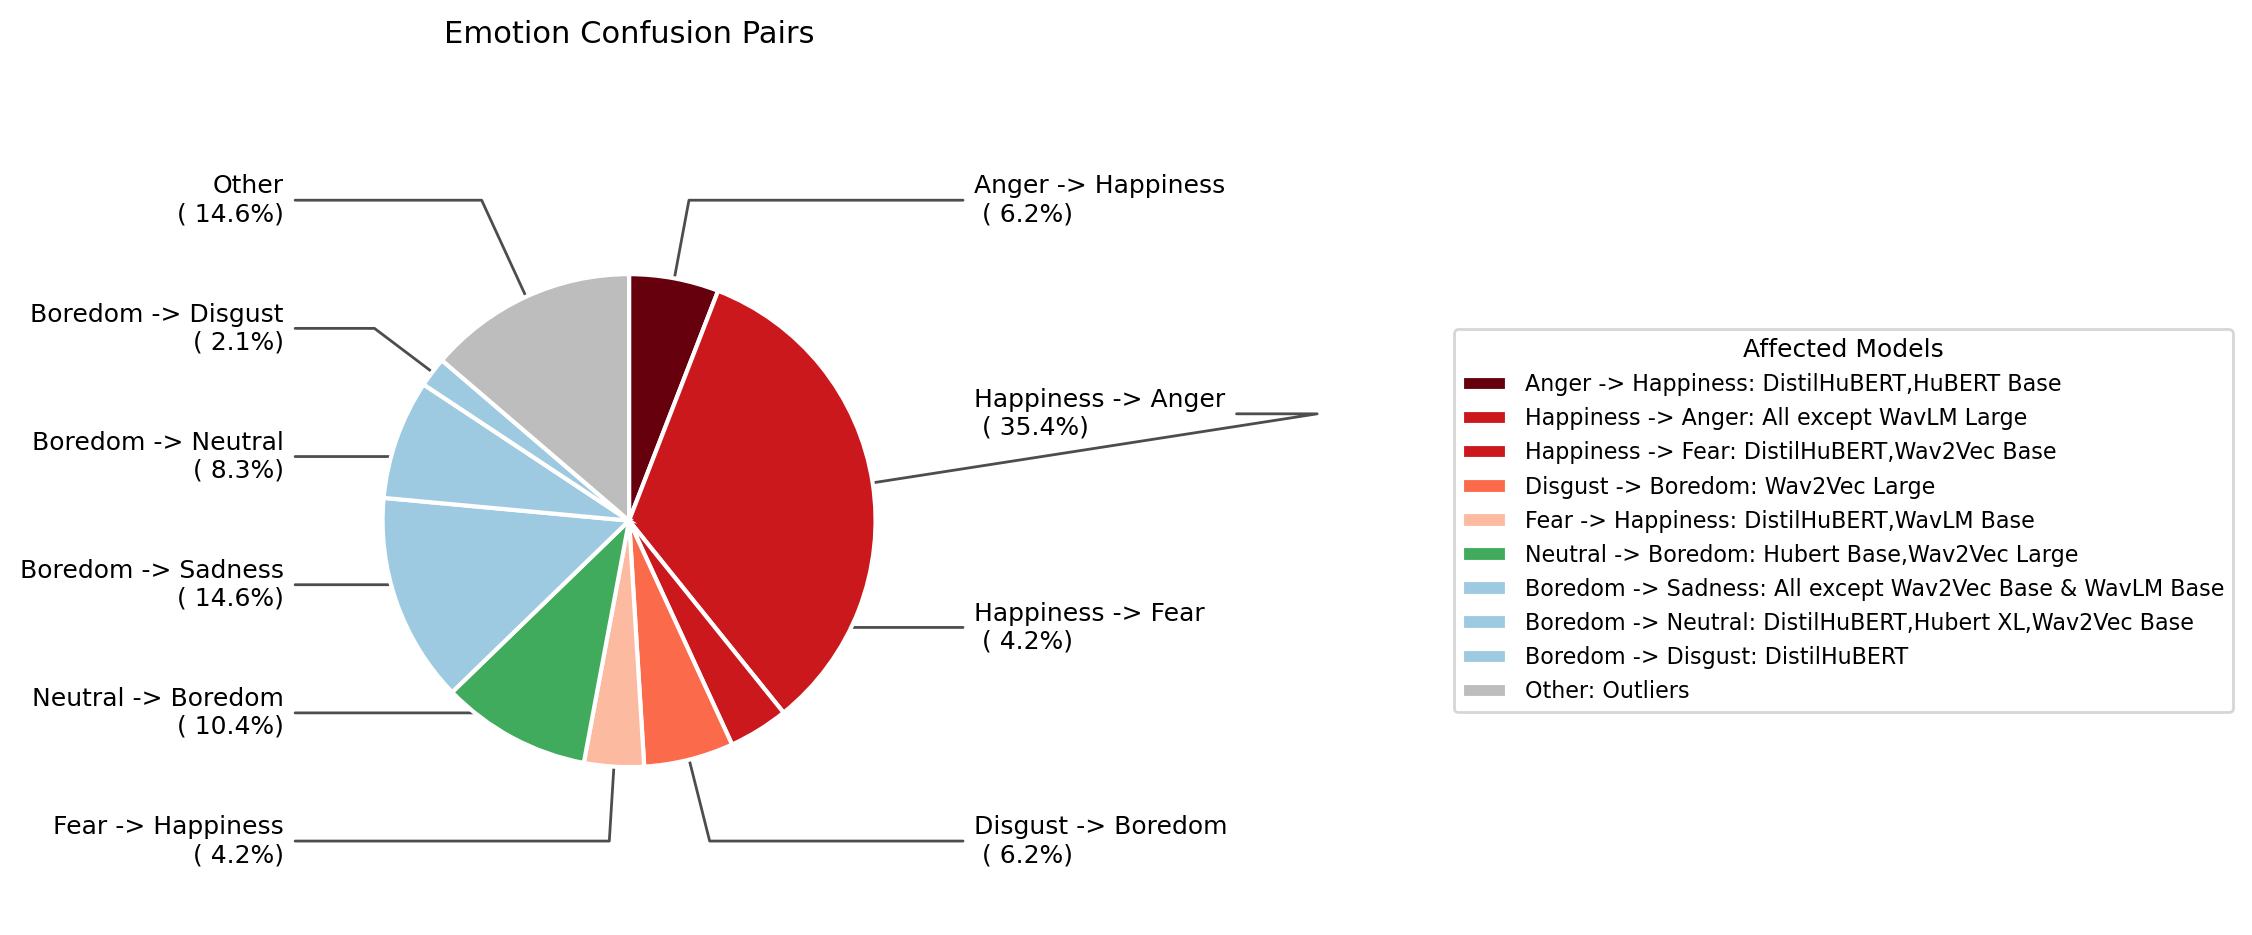

In [88]:
import matplotlib.cm as cm 
emo_pair_counts = {
    ("Happiness", "Anger") : {"count": 17, "models": ["All except WavLM Large"]},
    ("Anger", "Happiness") : {"count": 3, "models": ["DistilHuBERT", "HuBERT Base"]},
    ("Happiness", "Fear") : {"count": 2, "models": ["DistilHuBERT", "Wav2Vec Base"]},
    ("Fear", "Happiness") : {"count": 2, "models": ["DistilHuBERT", "WavLM Base"]},
    ("Boredom", "Sadness") : {"count": 7, "models": ["All except Wav2Vec Base & WavLM Base"]},
    ("Boredom", "Disgust") : {"count": 1, "models": ["DistilHuBERT"]},
    ("Disgust", "Boredom") : {"count": 3, "models": ["Wav2Vec Large"]},
    ("Boredom", "Neutral") : {"count": 4, "models": ["DistilHuBERT", "Hubert XL", "Wav2Vec Base"]},
    ("Neutral", "Boredom") : {"count": 5, "models": ["Hubert Base", "Wav2Vec Large"]},
    ("Other", "Other"): {"count": 7, "models": ["Outliers"]},
}

total_errors = 48

emo_colour =  {
    "Anger" : "#67000d",   #highest arousal = darkest shade of red
    "Happiness": "#cb181d", 
    "Disgust": "#fb6a4a",
    "Fear": "#fcbba1", 
    "Neutral": "#41ab5d", #green 
    "Boredom": "#9ecae1", # light blue for it being a low arousal emotion 
    "Other": "#bdbdbd"
}

emo_order = ["Anger", "Happiness", "Disgust", "Fear", "Neutral", "Boredom", "Other" ]
pairs = sorted(emo_pair_counts.keys(), key = lambda k: (emo_order.index(k[0]), -emo_pair_counts[k]["count"]))
counts = [emo_pair_counts[p]["count"] for p in pairs]
models_per_pair = [emo_pair_counts[p]["models"] for p in pairs]
colours = [emo_colour[true] for (true, _) in pairs]
labels = ["Other" if t == "Other"  else f"{t} -> {p}" for (t,p) in pairs]
emotion_pair_errors = sum(counts)

fig, ax = plt.subplots(figsize= (12,9), dpi=200)
wedges, _ = ax.pie(counts, colors=colours, startangle=90, counterclock=False, wedgeprops=dict(edgecolor="white", linewidth=1.5))

angles = [(w.theta2 - w.theta1) / 2 + w.theta1 for w in wedges]
xs = [np.cos(np.deg2rad(a)) for a in angles]
ys = [np.sin(np.deg2rad(a)) for a in angles]
right_index = [i for i in range(len(wedges)) if xs[i] >= 0]
left_index = [i for i in range(len(wedges)) if xs[i] < 0]
right_index.sort(key=lambda i: -ys[i])
left_index.sort(key=lambda i: -ys[i])

label_ytext = {}
for index_group in (right_index, left_index):
    n = len(index_group)
    if n == 0: 
        continue
    y_pos = np.linspace(1.3, -1.3, n) if n> 1 else [0.0]
    for i, index in enumerate(index_group): 
        label_ytext[index] = y_pos[i]
        

keywords = dict(arrowprops=dict(arrowstyle="-", color="0.3", lw=1), zorder=0, va="center")
for i, wedge in enumerate(wedges): 
    x, y = xs[i], ys[i]
    horizontalalignment = "left" if x>= 0 else "right"
    connectionstyle = f"angle, angleA=0, angleB={angles[i]}"
    keywords["arrowprops"].update({"connectionstyle": connectionstyle})
    perc = counts[i] / total_errors *100

    x_text = 1.4 * np.sign(x) if x !=0 else 1.4
    y_text = label_ytext[i]
    
    ax.annotate(f"{labels[i]}\n ({perc: .1f}%)", xy=(x* 0.95, y*0.95), xytext=(x_text, y_text), horizontalalignment = horizontalalignment, fontsize=9, **keywords)
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-1.6, 1.6)

ax.set_title("Emotion Confusion Pairs", fontsize=11, pad=30)
legend_labels = [f"{labels[i]}: {",".join(models_per_pair[i]) or "N/A"}" for i in range(len(pairs))]
ax.legend(wedges, legend_labels, title="Affected Models", loc="center left", bbox_to_anchor=(1.25, 0, 0.5, 1), fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig("Misclassified Emotion Pairs.png", bbox_inches = "tight")
plt.show()
                


For identifying the order of emotions by high-low arousal:   
https://www.researchgate.net/figure/Emotions-in-valence-arousal-space-13_fig3_329718637    
https://www.researchgate.net/figure/Visualization-of-emotion-classification-a-High-Arousal-HA-and-Low-Arousal-LA_fig1_397725290

## Visualising the SNR of all files in the test set and the misclassified files among them 

<Figure size 640x480 with 0 Axes>

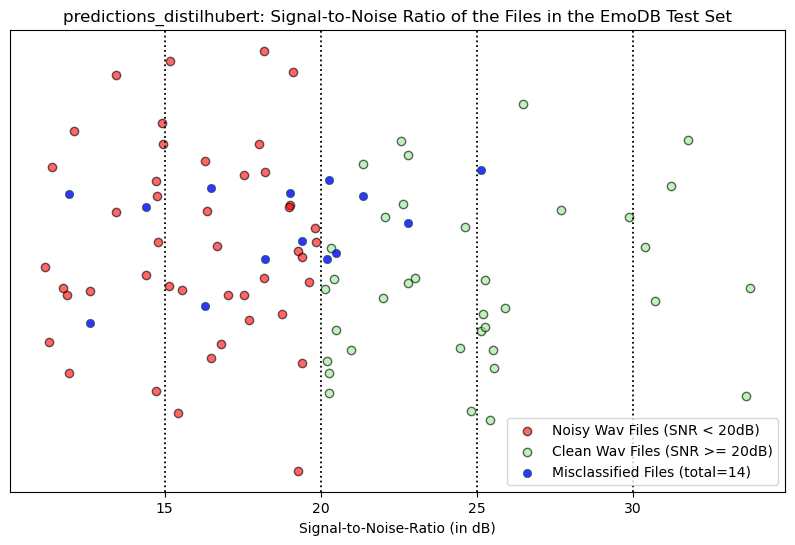

<Figure size 640x480 with 0 Axes>

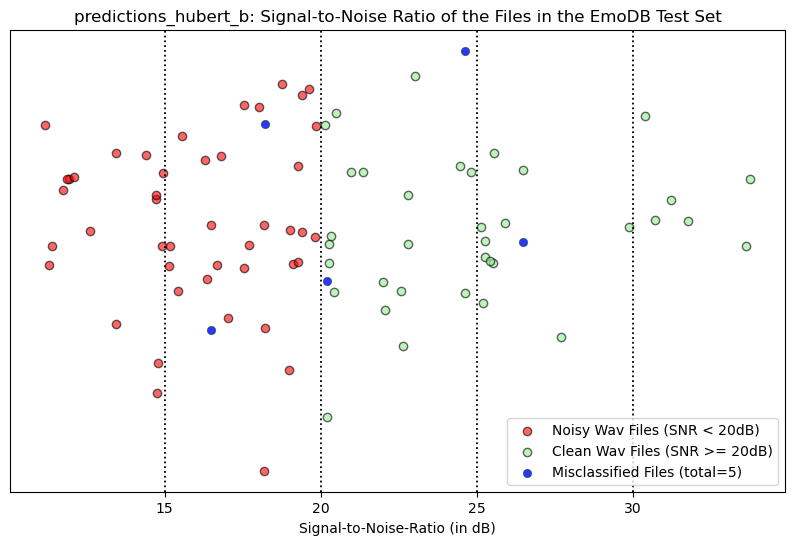

<Figure size 640x480 with 0 Axes>

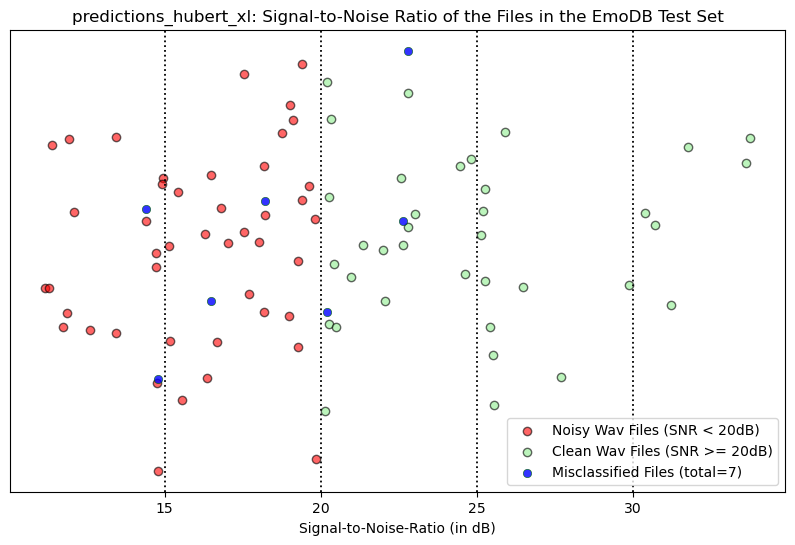

<Figure size 640x480 with 0 Axes>

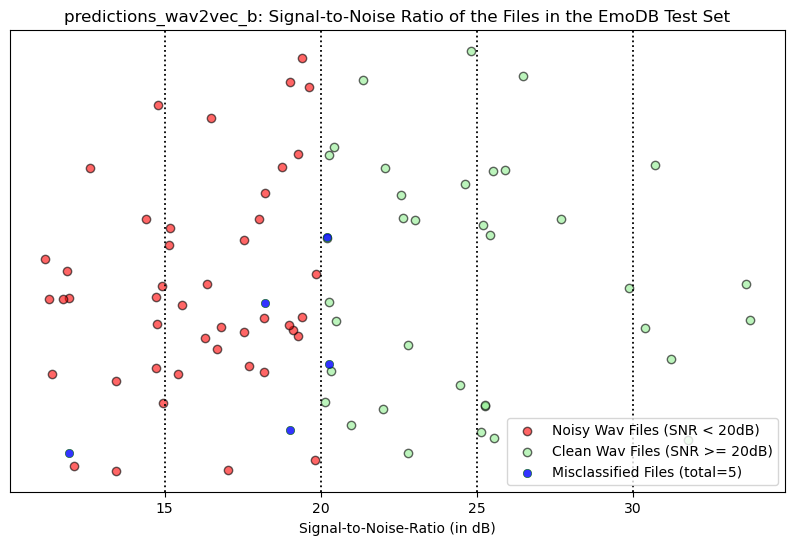

<Figure size 640x480 with 0 Axes>

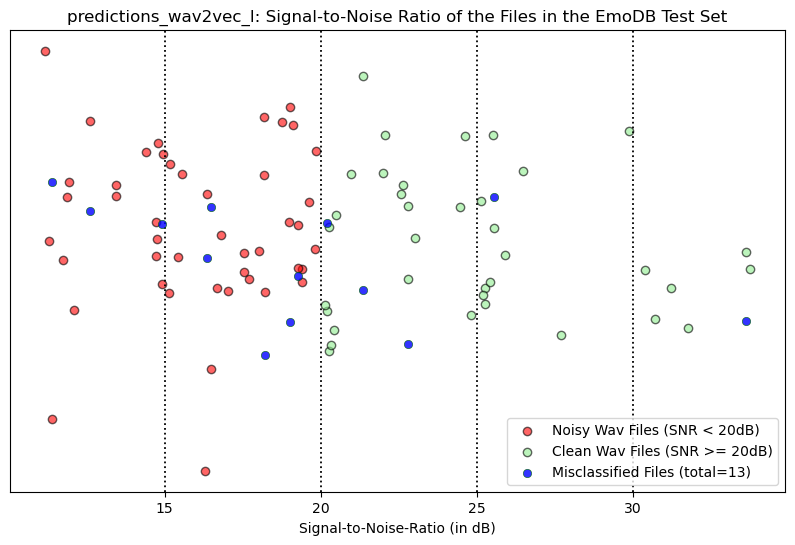

<Figure size 640x480 with 0 Axes>

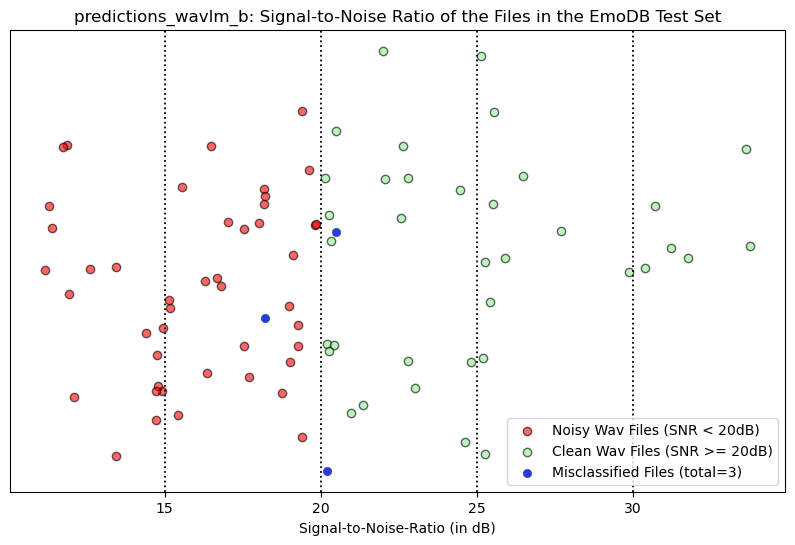

<Figure size 640x480 with 0 Axes>

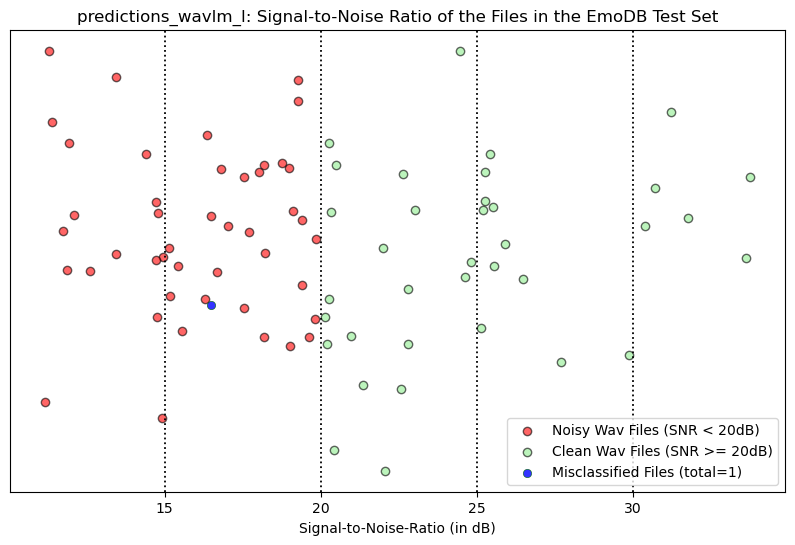

In [27]:
import matplotlib.pyplot as plt

for model_name, path in pred_files.items():
    plt.clf()

    test_df = pd.read_csv(path, sep=None, engine="python")
    test_filenames = set(test_df["audio_file"])

    noisy_test = [x for x in noisy_files if x[0] in test_filenames]
    noisy_snr_values = [x[1] for x in noisy_test]
    ynoisy = np.random.normal(0, 0.04, size= len(noisy_snr_values))
    
    clean_test = [x for x in clean_files if x[0] in test_filenames]
    clean_snr_values = [x[1] for x in clean_test]
    yclean= np.random.normal(0, 0.04, size=len(clean_snr_values))

    df = all_wrong_files[model_name]
    wrong_snr_values = df["snr"].dropna().tolist()
    ywrong = np.random.normal(0, 0.04, size=len(wrong_snr_values))
    
    plt.figure(figsize=(10,6))
    plt.scatter(noisy_snr_values, ynoisy, color="r", label="Noisy Wav Files (SNR < 20dB)", alpha=0.6, edgecolors="k")
    plt.scatter(clean_snr_values, yclean, color="lightgreen", label="Clean Wav Files (SNR >= 20dB)", alpha=0.6, edgecolors="k")

    if wrong_snr_values: 
        plt.scatter(wrong_snr_values, ywrong, color = "b", edgecolors="darkgreen", label= f"Misclassified Files (total={len(wrong_snr_values)})", alpha=0.8, linewidth=0.5, zorder=5)
    plt.xlabel("Signal-to-Noise-Ratio (in dB)")
    plt.title(f"{model_name}: Signal-to-Noise Ratio of the Files in the EmoDB Test Set")
    plt.legend(loc="lower right")
    plt.grid(axis="x", ls=":", color= "k", linewidth= 1.3, zorder=0)

    plt.gca().axes.get_yaxis().set_visible(False)


    plt.show()

>> Finding: 
Other than for WavLM Large, there are always misclassified clean files as well. While they do not necessairly outnumber the number of misclassified noisy files, it should be noted that (including the case for WavLM Large) each model managed to correctly classify at least one emotion for a sound file with a lower SNR than the lowest SNR of the misclassified file. This gives us a first hint that noise does not play as big of a role here as it might initially seem. 

### Defining a function for further analysis of files that have a negative snr gap, hence were potentially misclassified due to noise; the function looks at the percentage of the misclassified noisy and clean files of the confused emotion pairs based on the number of clean and noisy files of the target emotion in the test set

In [32]:
def misclassification_rate(csv_path, snr_df, model_name, true_label=None, pred_label=None, snr_treshold=20.0):
    df = load_preds(csv_path, snr_df)

    class_df = df[df[true_col] == true_label].copy()
    if class_df["snr_db"].isna().all():
        return None

    class_df["snr_group"] = class_df["snr_db"].apply(lambda x: "noisy" if x < snr_treshold else "clean")

    if pred_label is not None: 
        class_df["is_error"] = (class_df["correct"] == False) & (class_df[pred_col] == pred_label)
    else: 
        class_df["is_error"] = class_df["correct"] == False

    summary = class_df.groupby("snr_group").agg(total_files=("is_error", "size"), misclassified=("is_error", "sum"))
    summary["misclassification_rate_perc"] = round(summary["misclassified"] / summary["total_files"] * 100, 2)

    label_str = f"{true_label} -> {pred_label}" if pred_label else f"{true_label} (error)"
    print(f"\n {model_name}: misclassification rate by SNR Groups (Noisy/Clean) for {label_str}")
    print(summary)

    return summary 


## Defining a function for checking for gender bias within the emotion class 

In [20]:
def gender_bias_misclassified_emotion_pair(csv_path, snr_df, model_name, true_label, pred_label, gender, target_speaker):
    df = load_preds(csv_path, snr_df)
    class_df = df[(df[true_col] == true_label) & (df["gender"] == gender)].copy()

    if class_df.empty: 
        return 

    print(f"\n{model_name}: '{true_label}' files from {gender} speakers, checking for '{true_label}' -> '{pred_label}' confusion")

    for speaker_id, group in class_df.groupby("speaker_id"):
        wrong = group[group["correct"] == False]
        marker = " <- target speaker" if speaker_id == target_speaker else ""

        if wrong.empty: 
            print(f" Speaker {speaker_id}: {len(group)} files, all correct{marker}")
        else: 
            wrong_preds = wrong[pred_col].tolist()
            matches_target_pair = pred_label in wrong_preds
            flag = "(matches the target confusion pair)" if matches_target_pair else ""
            print(f"Speaker {speaker_id}: {len(group)} files, {len(wrong)} wrongly predicted as {wrong_preds}{flag}{marker}")

    

#### a) Checking for happiness -> anger 

>> What we know already:
>>  - the snr_gap based on averaged snr values being negative across all models and presence of multiple speaker suggest noise as a cause for misclassification
>>  - except for WavLM Large, all models classified the same recording of speaker 9 and 14, both female
>>  - distilhubert and hubert xl also struggled with one identical female recording of speaker 16
>>  - distilhubert and hubert xl and wav2vec large also struggled to correctly classify the same male recording of speaker 11

In [33]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="happiness", pred_label="anger")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> anger
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                6              2                        33.33
noisy                5              2                        40.00

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> anger
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                6              1                        16.67
noisy                5              1                        20.00

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> anger
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                6         

>> Finding: considering the small sample sizes (5 noisy, 6 clean files), the misclassification rate between noisy and clean files is not that noteworthy. Hence, the earlier hypothesis of noise being the reason for the misclassification needs to be invalidated. Checking for gender bias since three female and one male speaker were involved in the misclassifications

In [16]:
for model_name, path in pred_files.items(): 
    gender_bias_misclassified_emotion_pair(path, snr_df, model_name, true_label="happiness", pred_label="anger", gender="female", target_speaker=16)


predictions_distilhubert: 'happiness' files from female speakers, checking for 'happiness' -> 'anger' confusion
Speaker 8: 1 files, 1 wrongly predicted as ['disgust']
Speaker 9: 1 files, 1 wrongly predicted as ['anger'](matches the target confusion pair)
Speaker 14: 4 files, 1 wrongly predicted as ['anger'](matches the target confusion pair)
Speaker 16: 3 files, 1 wrongly predicted as ['anger'](matches the target confusion pair) <- target speaker

predictions_hubert_b: 'happiness' files from female speakers, checking for 'happiness' -> 'anger' confusion
 Speaker 8: 1 files, all correct
Speaker 9: 1 files, 1 wrongly predicted as ['anger'](matches the target confusion pair)
Speaker 14: 4 files, 1 wrongly predicted as ['anger'](matches the target confusion pair)
 Speaker 16: 3 files, all correct <- target speaker

predictions_hubert_xl: 'happiness' files from female speakers, checking for 'happiness' -> 'anger' confusion
 Speaker 8: 1 files, all correct
Speaker 9: 1 files, 1 wrongly pred

>> Finding:
>> If there was a bias towards female speakers, we would not see any of their files getting predicted correctly. Looking at the amount of times Speaker 9 appears in the misclassified emotion pairs for example, it is noticable that speaker 9 is among the misclassified speaker files only in the emotion pairs happiness -> anger, anger -> happiness. One might want to take a look at the overall correctly classified emotions of the individual speakers to check for speaker-specific misclassficiation 

### Defining a function to test for speaker specific characteristic and/or speaker bias

In [20]:
def test_speaker_bias(csv_path): 
    df = pd.read_csv(csv_path, sep=None, engine="python")
    if df["correct"].dtype == object:
        df["correct"] = df["correct"].astype(str).str.strip().str.lower() == "true"

    df["speaker_id"] = df["audio_file"].str[:2].astype(int)
    df["gender"] = df["speaker_id"].apply(get_gender)

    total_per_speaker = df.groupby("speaker_id").size()
    wrong_per_speaker = df[df["correct"] == False].groupby("speaker_id").size()

    bias_analysis_df = pd.DataFrame({
        "total_files": total_per_speaker, 
        "wrong_files": wrong_per_speaker
    }).fillna(0).astype(int)

    bias_analysis_df["gender"] = bias_analysis_df.index.map(get_gender)
    bias_analysis_df["accuracy_in_percentage"] = round((bias_analysis_df["total_files"] - bias_analysis_df["wrong_files"]) / bias_analysis_df["total_files"] * 100, 2)
    bias_analysis_df = bias_analysis_df.sort_values("accuracy_in_percentage", ascending = False)

    for speaker_id, row in bias_analysis_df.iterrows(): 
        print(f"Speaker {speaker_id}, {row["gender"]}: {row["accuracy_in_percentage"]}% of the files in the test set were correctly classified ( misclassified were {row["wrong_files"]}/{row["total_files"]})")

    return bias_analysis_df

for model_name, path in pred_files.items(): 
    print(f"\n ** {model_name} **")
    test_speaker_bias(path)


 ** predictions_distilhubert **
Speaker 13, female: 100.0% of the files in the test set were correctly classified ( misclassified were 0/8)
Speaker 10, male: 100.0% of the files in the test set were correctly classified ( misclassified were 0/5)
Speaker 14, female: 92.86% of the files in the test set were correctly classified ( misclassified were 1/14)
Speaker 11, male: 87.5% of the files in the test set were correctly classified ( misclassified were 1/8)
Speaker 16, female: 81.82% of the files in the test set were correctly classified ( misclassified were 2/11)
Speaker 15, male: 80.0% of the files in the test set were correctly classified ( misclassified were 2/10)
Speaker 12, male: 75.0% of the files in the test set were correctly classified ( misclassified were 1/4)
Speaker 3, male: 75.0% of the files in the test set were correctly classified ( misclassified were 2/8)
Speaker 8, female: 62.5% of the files in the test set were correctly classified ( misclassified were 3/8)
Speaker 9

_________________

### Noticable Speaker Accuracy Patterns 
**Speaker 9**: other than wavLM-large she occurs in every model with misclassified emotions (lowest accuracy = 60%)   
**Speaker 3**: other than in the wavLM_b model, he occurs in all misclassified emotions (lowest accuracy = 75%)    
**Speaker 16**: other than wavLM_l and wav2vec_b, they all got speaker 16 wrong. (lowest accuracy = 72.73% but very varying accruracy also sometimes 90.91% for both hubert models (audio files differ though) and 81.82% for eg distilhubert)     
**Speaker 12**: his recordings are either perfectly classified by the model or the accuracy regarding them is among the lowest ones of th emodel (lowest accuracy 75%)     
**Speaker 8**: for 4/7 models, speaker 8's recoridngs are identified perfectly but then for the other it varies eg distilhubert 62.5%, 87.5%, 75%     

(**Speaker 14**: other than for wavLM_l, all models get the same percentage of speaker 14 files wrong an dupon further analysis it turns out they all get the same audio file wrong, they think it is anger although it is happiness; listening to it myself I would come to the anger conclusion as well; so we dont have a speaker bias here but maybe a labeling error or bad acting)


__________________________________

>> Findings: 
Together the earlier overview table and this speaker file accuracy list show that all models except WavLM Large struggled with the recordings of Speaker 9 when it came to the happiness <- -> anger emotion pair (60-80% accuracy, almost exclusively among the lowest performing files), which suggests that her way of expressing happiness and anger might be very similar hence hard for the models to detect. Listening to the files, the file assigned as happiness for number 14 does not sound as such but rather as anger. Listening to the file of speaker 11, which is supposed to be happiness, I would  have labeled it differently, namely as neutral but the model chose angry. 
>>  -  Speaker 9: Prosodic Overlap between the emotions anger and happiness 
>>  -  Speaker 14: potentially mislabeled recording by the annotators (14b09Fc)
>>  -  for speaker 11: weakly expressed emotion (me, ground truth, model disagree)
>>  -  for speaker 16: checking if it had sth to do with file duration. what we can say however at this point already is that if it had sth to do with the duration of the file, it would be a model-specific bias because that very file has been correctly classified by 5/7 models, which speaks against a longer/shorter happiness-file of the speaker being in general difficult to classify 

## Defining a function that checks for file duration of the speaker files 

In [3]:
import soundfile as sf
import librosa
from pathlib import Path
filepath = r"C:\path\to\file\emodb\wav"
records = []

for wav in Path(filepath).glob("*.wav"):
    duration = librosa.get_duration(path=wav)
    records.append({"audio_file": wav.name, "duration" :duration})

duration_df = pd.DataFrame(records)
df_w_duration = df.merge(duration_df, on="audio_file", how="left")

n_missing = df_w_duration["duration"].isna().sum()
if n_missing > 0: 
    print("Some rows don't have a duration")

df_w_duration["speaker"] = df_w_duration["audio_file"].str[:2].astype(int)

def analyse_duration(df, true, pred, target_speaker, speaker_col="speaker", true_col= "ground_truth", pred_col= "predicted", duration_col= "duration", filename_col = "audio_file"):
    target_incorrect = df[(df[speaker_col] == target_speaker) & (df[true_col] == true) & (df[pred_col] == pred) & (df[true_col] != df[pred_col])]
    target_correct = df[(df[speaker_col] == target_speaker) & (df[true_col] == true)  & (df[true_col] == df[pred_col])]
    others_correct = df[(df[speaker_col] != target_speaker) & (df[true_col] == true)  & (df[true_col] == df[pred_col])]
    others_incorrect = df[(df[speaker_col] != target_speaker) & (df[true_col] == true) & (df[pred_col] == pred) & (df[true_col] != df[pred_col])]

    groups = {
        f"Speaker {target_speaker} misclasified '{true}' -> '{pred}'" : target_incorrect, 
        f"Speaker {target_speaker} correctly clasified '{true}'" : target_correct, 
        f"Other speakers correctly clasified '{true}'" : others_correct,
        f"Other speakers misclasified '{true}' -> '{pred}'" : others_incorrect  }

    print(f"** Duration comparison: {true} -> {pred} of Speaker {target_speaker} **\n")

    for label, subset in groups.items():
        rows = subset[[filename_col, duration_col]].dropna().sort_values(duration_col)
        n = len(rows)
        print(f"{label} (n={n})")
        if n == 0: 
            print()
            continue

        for _, row in rows.iterrows(): 
            print(f"   {row[filename_col]:<20}: {row[duration_col]:>7.3f} sec")
        print()

    return groups 

## Defining a function that applies said file duration check across models

In [4]:
def analyse_duration_across_models(pred_files, duration_df, true, pred, target_speaker): 
    for model_name, csv_path in pred_files.items(): 
        print(f"**{model_name}**")

        model_df = pd.read_csv(csv_path, sep=None, engine="python")
        model_df_w_duration = model_df.merge(duration_df, on="audio_file", how="left")

        n_missing = model_df_w_duration["duration"].isna().sum()
        if n_missing > 0: 
            print(f"{n_missing} rows are missing for {model_name}")

        model_df_w_duration["speaker"] = model_df_w_duration["audio_file"].str[:2].astype(int)
        analyse_duration(model_df_w_duration, true=true, pred=pred, target_speaker=target_speaker)

In [5]:
analyse_duration_across_models(pred_files, duration_df, true="happiness", pred="anger", target_speaker=16)

**predictions_distilhubert**
** Duration comparison: happiness -> anger of Speaker 16 **

Speaker 16 misclasified 'happiness' -> 'anger' (n=1)
   16b03Fd.wav         :   3.657 sec

Speaker 16 correctly clasified 'happiness' (n=2)
   16a07Fa.wav         :   2.371 sec
   16b10Fb.wav         :   2.583 sec

Other speakers correctly clasified 'happiness' (n=3)
   14a02Fd.wav         :   1.682 sec
   14b01Fa.wav         :   2.560 sec
   14a05Fa.wav         :   3.246 sec

Other speakers misclasified 'happiness' -> 'anger' (n=3)
   09a01Fa.wav         :   1.831 sec
   14b09Fc.wav         :   2.530 sec
   11b09Fd.wav         :   3.037 sec

**predictions_hubert_b**
** Duration comparison: happiness -> anger of Speaker 16 **

Speaker 16 misclasified 'happiness' -> 'anger' (n=0)

Speaker 16 correctly clasified 'happiness' (n=3)
   16a07Fa.wav         :   2.371 sec
   16b10Fb.wav         :   2.583 sec
   16b03Fd.wav         :   3.657 sec

Other speakers correctly clasified 'happiness' (n=6)
   14a0

>> Finding:
>> The misclassified file of speaker 16 in distilbert and hubert xl is the longest file of all (3.657 sec), so this makes it seem like the models are biased to longer files. But lets analyse this closer 

## Defining a function which specifically looks at the length of all the misclassified files of a specific model for a specific target emotion

In [12]:
def misclassified_durations(csv_path, duration_df,true, true_col="ground_truth", pred_col="predicted", filename_col="audio_file", duration_col="duration"):
    df = pd.read_csv(csv_path, sep=None, engine="python")
    df_w_duration = df.merge(duration_df, on=filename_col, how="left")

    misclassified = df_w_duration[(df_w_duration[true_col] == true) & (df_w_duration[pred_col] != df_w_duration[true_col])]

    result = misclassified[[filename_col, pred_col, duration_col]].sort_values(duration_col)
    print(f"Misclassified '{true}' files (n={len(result)})")
    for _, row in result.iterrows(): 
        print(f"  {row[filename_col]:<20} -> {row[pred_col]:<10}: {row[duration_col]:>7.3f} sec")
    return result 

In [13]:
misclassified_durations(pred_files["predictions_distilhubert"], duration_df, true="happiness")

Misclassified 'happiness' files (n=6)
  09a01Fa.wav          -> anger     :   1.831 sec
  03a07Fa.wav          -> fear      :   2.134 sec
  08a01Fd.wav          -> disgust   :   2.300 sec
  14b09Fc.wav          -> anger     :   2.530 sec
  11b09Fd.wav          -> anger     :   3.037 sec
  16b03Fd.wav          -> anger     :   3.657 sec


,audio_file,predicted,duration
74,09a01Fa.wav,anger,1.831125
22,03a07Fa.wav,fear,2.133812
2,08a01Fd.wav,disgust,2.299750
59,14b09Fc.wav,anger,2.529500
42,11b09Fd.wav,anger,3.036563
33,16b03Fd.wav,anger,3.657437


In [18]:
misclassified_durations(pred_files["predictions_hubert_xl"], duration_df, true="happiness")

Misclassified 'happiness' files (n=4)
  09a01Fa.wav          -> anger     :   1.831 sec
  14b09Fc.wav          -> anger     :   2.530 sec
  11b09Fd.wav          -> anger     :   3.037 sec
  16b03Fd.wav          -> anger     :   3.657 sec


,audio_file,predicted,duration
74,09a01Fa.wav,anger,1.831125
59,14b09Fc.wav,anger,2.529500
42,11b09Fd.wav,anger,3.036563
33,16b03Fd.wav,anger,3.657437


>> Finding:
>> Seeing all misclassified happiness files together now for both the models, it does not seem at all like the Distilhubert or Hubert XL are biased against longer files when it comes to happiness. Otherwise the shorter ones would not have been spared from being misclassified.
>> - Speaker 16: Outlier


### b) Checking for anger -> happiness 

>> What we already know:
>> - the snr_gaps dont really say much because for distilbert it is negative and hubert-b it is positive, so we have to do a more detailed analysis of the snr gaps
>> - distilbert has 2 recordings from 2 speakers misclassified (9, 15) while hubert_b only has one misclassified from speaker 16
>> - for Speaker 9 it is more or less already clear that the reason for misclassification is prosodic overlap, so no further investigation here 
>> - Gender of the speakers is mixed (2 female, 1 male recording)

In [34]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="anger", pred_label="happiness")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for anger -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean               11              1                         9.09
noisy                8              1                        12.50

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for anger -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean               11              1                         9.09
noisy                8              0                         0.00

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for anger -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean               11         

>> Findings:
>> Noise does not seem to be the reason for misclassification of the anger files of 15 and 16. Considering that male as well as female recordings were among the misclassification, a gender bias check is skipped here but we will see about the duration length part. For distilhubert we already checked in the past, it does not discriminate against short or long files,  so no need to do that again. However, this also means that we have no actual further clue why the file of speaker 15 was misclassified. Listening to the file of speaker 15 has also only shown that it sounds like angry as well, still the model labeled it wrongly. 

>>We will take a closer look at the duration length bias for Distilhubert and Hubert base when it comes to the emotion "anger" to find out more about why the recording of speaker 15 and 16 were misclassified. We will exclusively focus on those two models since they were the only ones that had issues assigning the correct label to anger by assigning it happiness. 

In [55]:
analyse_duration_across_models(pred_files, duration_df, true="anger", pred="happiness", target_speaker=16)

**predictions_distilhubert**
** Duration comparison: anger -> happiness of Speaker 16 **

Speaker 16 misclasified 'anger' -> 'happiness' (n=0)

Speaker 16 correctly clasified 'anger' (n=2)
   16a01Wb.wav         :   2.200 sec
   16b02Wb.wav         :   3.184 sec

Other speakers correctly clasified 'anger' (n=15)
   14a02Wa.wav         :   2.013 sec
   14a02Wc.wav         :   2.093 sec
   03a02Wb.wav         :   2.124 sec
   12a01Wc.wav         :   2.359 sec
   12b10Wa.wav         :   2.549 sec
   09b09Wa.wav         :   2.622 sec
   15b02Wc.wav         :   2.623 sec
   10b10Wa.wav         :   2.646 sec
   14b10Wc.wav         :   2.655 sec
   11b10Wa.wav         :   2.886 sec
   08b09Wa.wav         :   3.166 sec
   08b02Wd.wav         :   3.584 sec
   14a05Wa.wav         :   4.007 sec
   11a05Wd.wav         :   4.038 sec
   11b03Wb.wav         :   5.213 sec

Other speakers misclasified 'anger' -> 'happiness' (n=2)
   09a07Wd.wav         :   2.319 sec
   15b01Wc.wav         :   2.631 sec

In [29]:
analyse_duration_across_models(pred_files, duration_df, true="anger", pred="happiness", target_speaker=15)

**predictions_distilhubert**
** Duration comparison: anger -> happiness of Speaker 15 **

Speaker 15 misclasified 'anger' -> 'happiness' (n=1)
   15b01Wc.wav         :   2.631 sec

Speaker 15 correctly clasified 'anger' (n=1)
   15b02Wc.wav         :   2.623 sec

Other speakers correctly clasified 'anger' (n=16)
   14a02Wa.wav         :   2.013 sec
   14a02Wc.wav         :   2.093 sec
   03a02Wb.wav         :   2.124 sec
   16a01Wb.wav         :   2.200 sec
   12a01Wc.wav         :   2.359 sec
   12b10Wa.wav         :   2.549 sec
   09b09Wa.wav         :   2.622 sec
   10b10Wa.wav         :   2.646 sec
   14b10Wc.wav         :   2.655 sec
   11b10Wa.wav         :   2.886 sec
   08b09Wa.wav         :   3.166 sec
   16b02Wb.wav         :   3.184 sec
   08b02Wd.wav         :   3.584 sec
   14a05Wa.wav         :   4.007 sec
   11a05Wd.wav         :   4.038 sec
   11b03Wb.wav         :   5.213 sec

Other speakers misclasified 'anger' -> 'happiness' (n=1)
   09a07Wd.wav         :   2.319 sec

>> Findings:
>> Regarding Speaker 16, if duration had been the reason, hubert b would not have gotten as many recordings with shorter and longer duration than the target file of speaker 16 right. As for speaker 15 the result is the same. Listening to both recordings revealed that the label was accurately assigned by the annotators, however, the models still got them wrong for the respective recordings.
>> - Speaker 15: outlier
>> - speaker 16: outlier 

## c) Checking  happiness -> fear 

>> What we already know:
>> - distilhubert and wav2vec base misclassified the same audio file of speaker 3 (male)
>> - since the snr gaps for the models are both negative (and we only have one audio file for the confused emotion pair, which is very inconclusive in itself), we have to further analyse the misclassification rate of the noisy and clean files to find out if noise is truly the culprit here
>> - only one male file was misclassified per model, likely has something to do with the speaker itself, so we will not check for gender bias
>> - since these two models were the only ones that misclassified the file, a general difficulty of all models with the file-length can be ruled out 

In [35]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="happiness", pred_label="fear")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> fear
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                6              1                        16.67
noisy                5              0                         0.00

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> fear
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                6              0                          0.0
noisy                5              0                          0.0

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> fear
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                6            

>> Finding:
>> For the misclassification noise cannot be the issue since the file belongs to the clean files. We will check for both,  distilhubert and wav2vec base if file duration is the reason for misclassiciation:

In [57]:
analyse_duration_across_models(pred_files, duration_df, true="happiness", pred="fear", target_speaker=3)

**predictions_distilhubert**
** Duration comparison: happiness -> fear of Speaker 3 **

Speaker 3 misclasified 'happiness' -> 'fear' (n=1)
   03a07Fa.wav         :   2.134 sec

Speaker 3 correctly clasified 'happiness' (n=0)

Other speakers correctly clasified 'happiness' (n=5)
   14a02Fd.wav         :   1.682 sec
   16a07Fa.wav         :   2.371 sec
   14b01Fa.wav         :   2.560 sec
   16b10Fb.wav         :   2.583 sec
   14a05Fa.wav         :   3.246 sec

Other speakers misclasified 'happiness' -> 'fear' (n=0)

**predictions_hubert_b**
** Duration comparison: happiness -> fear of Speaker 3 **

Speaker 3 misclasified 'happiness' -> 'fear' (n=0)

Speaker 3 correctly clasified 'happiness' (n=1)
   03a07Fa.wav         :   2.134 sec

Other speakers correctly clasified 'happiness' (n=8)
   14a02Fd.wav         :   1.682 sec
   08a01Fd.wav         :   2.300 sec
   16a07Fa.wav         :   2.371 sec
   14b01Fa.wav         :   2.560 sec
   16b10Fb.wav         :   2.583 sec
   11b09Fd.wav    

>> Finding: Considering that distilhubert and wav2vec base did also misclassify files in a lower and higher duration range than the file of speaker 3 has, we can also rule out file length as a emotion bias here. Listening to the file itself, the label seems to be accurate. However, listening to the recording, it sounds a little breathy, so it might be a shared acoustic characteristic shared between the happiness expressed in the recording and the model's understanding of fear, which made it choose a different label 
>> - Speaker 3: shared acoustic characteristic (paralinguistic overlap)

## d) Checking fear -> happiness 

>> What we already know:
>> - the snr gap is positive, which rules out noise as a cause for misclassification and points towards speaker-specific factors; no further analysis of snr needed
>> - distilhubert and wavlm_base misclassified the same recording of speaker 16 (female)
>> - since only one speaker is involved, this is likely speaker-specific
>> - similar to how we handled the situation with speaker three, we will also not take a look at the gender bias here

In [58]:
analyse_duration_across_models(pred_files, duration_df, true="fear", pred="happiness", target_speaker=16)

**predictions_distilhubert**
** Duration comparison: fear -> happiness of Speaker 16 **

Speaker 16 misclasified 'fear' -> 'happiness' (n=1)
   16a05Ab.wav         :   2.901 sec

Speaker 16 correctly clasified 'fear' (n=1)
   16b01Aa.wav         :   2.081 sec

Other speakers correctly clasified 'fear' (n=9)
   03a04Ad.wav         :   1.505 sec
   15a04Ac.wav         :   1.844 sec
   14b01Ac.wav         :   2.344 sec
   11b10Ad.wav         :   2.446 sec
   10b02Aa.wav         :   2.462 sec
   13b09Ab.wav         :   2.712 sec
   13a05Aa.wav         :   2.792 sec
   11a05Ad.wav         :   2.916 sec
   14b03Ad.wav         :   3.503 sec

Other speakers misclasified 'fear' -> 'happiness' (n=0)

**predictions_hubert_b**
** Duration comparison: fear -> happiness of Speaker 16 **

Speaker 16 misclasified 'fear' -> 'happiness' (n=0)

Speaker 16 correctly clasified 'fear' (n=2)
   16b01Aa.wav         :   2.081 sec
   16a05Ab.wav         :   2.901 sec

Other speakers correctly clasified 'fear' (

>> Findings:
>> File length does not seem to influence the models' decision to assign the label "fear" as for both, distilhubert and wavlm base there were files of lower, equal and higher duration length, which were classified correctly, while the one of speaker 16 was not. Listening to the recording it does sound like fear, however, I also noticed that the audio file was quite fast-paced, so maybe that is why the model confused it with happiness? This would indicate a potential arousal overlap.
>> - Speaker 16: prosodic overlap

## e) Checking boredom -> sadness 

>> What we already know:
>> - the snr gap is positive, so likely speaker-specific ; no further analysis needed of snr
>> - all models except WavLM Base and wav2vec base confused the same file of speaker 3 (male)
>> - distilhubert & wav2vec large also confused the same file of speaker 15 (male)
>> - check will be made regarding gender bias of the emotion pair

In [44]:
for model_name, path in pred_files.items(): 
    gender_bias_misclassified_emotion_pair(path, snr_df, model_name, true_label="boredom", pred_label="sadness", gender="male", target_speaker=3)


predictions_distilhubert: 'boredom' files from male speakers, checking for 'boredom' -> 'sadness' confusion
Speaker 3: 3 files, 1 wrongly predicted as ['sadness'](matches the target confusion pair) <- target speaker
 Speaker 10: 2 files, all correct
Speaker 12: 1 files, 1 wrongly predicted as ['neutral']
Speaker 15: 2 files, 1 wrongly predicted as ['sadness'](matches the target confusion pair)

predictions_hubert_b: 'boredom' files from male speakers, checking for 'boredom' -> 'sadness' confusion
Speaker 3: 3 files, 1 wrongly predicted as ['sadness'](matches the target confusion pair) <- target speaker
 Speaker 10: 2 files, all correct
 Speaker 12: 1 files, all correct
 Speaker 15: 2 files, all correct

predictions_hubert_xl: 'boredom' files from male speakers, checking for 'boredom' -> 'sadness' confusion
Speaker 3: 3 files, 2 wrongly predicted as ['sadness', 'neutral'](matches the target confusion pair) <- target speaker
 Speaker 10: 2 files, all correct
 Speaker 12: 1 files, all co

In [46]:
for model_name, path in pred_files.items(): 
    gender_bias_misclassified_emotion_pair(path, snr_df, model_name, true_label="boredom", pred_label="sadness", gender="female", target_speaker=16)


predictions_distilhubert: 'boredom' files from female speakers, checking for 'boredom' -> 'sadness' confusion
Speaker 8: 1 files, 1 wrongly predicted as ['disgust']
 Speaker 13: 3 files, all correct

predictions_hubert_b: 'boredom' files from female speakers, checking for 'boredom' -> 'sadness' confusion
 Speaker 8: 1 files, all correct
 Speaker 13: 3 files, all correct

predictions_hubert_xl: 'boredom' files from female speakers, checking for 'boredom' -> 'sadness' confusion
 Speaker 8: 1 files, all correct
Speaker 13: 3 files, 1 wrongly predicted as ['neutral']

predictions_wav2vec_b: 'boredom' files from female speakers, checking for 'boredom' -> 'sadness' confusion
 Speaker 8: 1 files, all correct
 Speaker 13: 3 files, all correct

predictions_wav2vec_l: 'boredom' files from female speakers, checking for 'boredom' -> 'sadness' confusion
 Speaker 8: 1 files, all correct
 Speaker 13: 3 files, all correct

predictions_wavlm_b: 'boredom' files from female speakers, checking for 'bored

>> Findings:
>> While the boredom female speaker audio files are not confused a single time with sadness, it should be noted that they involve only two speakers in total while the male boredom audio files involve four speaker, making up for 4 female recordings and 8 male recordings. Misclassified as sadness are only 2 out of 4 of these male speakers, with speaker 15 and 12 also being correctly classified from time to time and speaker 10 being correctly classified as boredom every single time. If there truly was a gender-bias then the models, even their weakest one (distilhubert) should not have gotten any classifications of male boredom recordings right but they did since speaker 10 was correctly classified across models. So we do not have a gender bias against male recordings here. What can be noted however, is that the models, when they confuse boredom, they confuse it with neutral (no arousal emotion) or sadness (low-arousal emotion), while for the two female boredom recording, this pattern does not hold (one time misclassified as neutral only, the other time as disgust = high-arousal). Looking just at the male boredom misclassifications, it seems that all models except wavLM base have issues distinguishing among male no- and low-arousal emotions to some degree.
>> - Looking at the EDA of the EmoDB Dataset, this could be explained by the inherent underrepresentation of male speakers within the whole dataset (233 male vs 302 female audio files) and a noticable gap of representation in the categories boredom (43.2% male vs 56.8% female) and sadness (59.7% female vs 40.3% male)  (neutral is almost balanced).

In [59]:
analyse_duration_across_models(pred_files, duration_df, true="boredom", pred="sadness", target_speaker=3)

**predictions_distilhubert**
** Duration comparison: boredom -> sadness of Speaker 3 **

Speaker 3 misclasified 'boredom' -> 'sadness' (n=1)
   03b02La.wav         :   3.465 sec

Speaker 3 correctly clasified 'boredom' (n=2)
   03a04Lc.wav         :   1.931 sec
   03b09La.wav         :   3.113 sec

Other speakers correctly clasified 'boredom' (n=6)
   13a02Lc.wav         :   1.784 sec
   10b01Lb.wav         :   2.057 sec
   10b10Lc.wav         :   2.270 sec
   15b01Lb.wav         :   2.327 sec
   13b09La.wav         :   2.590 sec
   13a05Lc.wav         :   3.353 sec

Other speakers misclasified 'boredom' -> 'sadness' (n=1)
   15b02Lb.wav         :   2.956 sec

**predictions_hubert_b**
** Duration comparison: boredom -> sadness of Speaker 3 **

Speaker 3 misclasified 'boredom' -> 'sadness' (n=1)
   03b02La.wav         :   3.465 sec

Speaker 3 correctly clasified 'boredom' (n=2)
   03a04Lc.wav         :   1.931 sec
   03b09La.wav         :   3.113 sec

Other speakers correctly clasified 

In [31]:
misclassified_durations(pred_files["predictions_distilhubert"], duration_df, true="boredom")

Misclassified 'boredom' files (n=4)
  15b02Lb.wav          -> sadness   :   2.956 sec
  03b02La.wav          -> sadness   :   3.465 sec
  12b03La.wav          -> neutral   :   3.945 sec
  08a05Lc.wav          -> disgust   :   4.188 sec


,audio_file,predicted,duration
72,15b02Lb.wav,sadness,2.955625
51,03b02La.wav,sadness,3.464812
19,12b03La.wav,neutral,3.944750
40,08a05Lc.wav,disgust,4.188375


>> Finding:
>> The length of the boredom files does seem to influence one out of 5 models, namely distilhubert. From 3.465sec (length file Speaker 3) onwards, it is unable to classify the files correctly. However, we might not take this as a sole reason for the misclassification of the file considering that there were four other models which also misclassified it.

In [60]:
analyse_duration_across_models(pred_files, duration_df, true="boredom", pred="sadness", target_speaker=15)

**predictions_distilhubert**
** Duration comparison: boredom -> sadness of Speaker 15 **

Speaker 15 misclasified 'boredom' -> 'sadness' (n=1)
   15b02Lb.wav         :   2.956 sec

Speaker 15 correctly clasified 'boredom' (n=1)
   15b01Lb.wav         :   2.327 sec

Other speakers correctly clasified 'boredom' (n=7)
   13a02Lc.wav         :   1.784 sec
   03a04Lc.wav         :   1.931 sec
   10b01Lb.wav         :   2.057 sec
   10b10Lc.wav         :   2.270 sec
   13b09La.wav         :   2.590 sec
   03b09La.wav         :   3.113 sec
   13a05Lc.wav         :   3.353 sec

Other speakers misclasified 'boredom' -> 'sadness' (n=1)
   03b02La.wav         :   3.465 sec

**predictions_hubert_b**
** Duration comparison: boredom -> sadness of Speaker 15 **

Speaker 15 misclasified 'boredom' -> 'sadness' (n=0)

Speaker 15 correctly clasified 'boredom' (n=2)
   15b01Lb.wav         :   2.327 sec
   15b02Lb.wav         :   2.956 sec

Other speakers correctly clasified 'boredom' (n=9)
   13a02Lc.wav 

>> Finding:
>> The file of speaker 15 with duration of 2.956 sec is still below the duration from which distilhubert starts discriminating boredom files, so it is not impacted by this behaviour. Similarly for the file size there is no reason to believe that wav2vec large would have discriminated it either as this model has correctly classified files with shorter as well as longer duration as well. Listening to speaker 15's audio file, the line seperating it from sadness is very thin, so maybe this is why 2/7 models got it wrong as well. As to the situation of speaker 3, listening to the audio file, one can also not strightforward identify this as boredom, it might as well be sadness which the speaker expresses. Considering that the best performing model, WavLM Large even struggled with this specific audio file and that the correctly labeled speaker recordings of speaker 3 regarding accuracy are mostly at the bottom 75-87.5% (except WavLM base), it might not be too far fetched to come to this ocnclusion: 
>> - Speaker 3: weakly expressed emotions (single file)
>> - Speaker 15: weakly expressed emotion (single file)

## f) Checking boredom -> disgust 

>> What we know already:
>> - only distilhubert misclassified a single recording, which is of speaker 8
>> - the snr gap is positive, so likely due to speaker specific reasons

In [39]:
analyse_duration_across_models(pred_files, duration_df, true="boredom", pred="disgust", target_speaker=8)

**predictions_distilhubert**
** Duration comparison: boredom -> disgust of Speaker 8 **

Speaker 8 misclasified 'boredom' -> 'disgust' (n=1)
   08a05Lc.wav         :   4.188 sec

Speaker 8 correctly clasified 'boredom' (n=0)

Other speakers correctly clasified 'boredom' (n=8)
   13a02Lc.wav         :   1.784 sec
   03a04Lc.wav         :   1.931 sec
   10b01Lb.wav         :   2.057 sec
   10b10Lc.wav         :   2.270 sec
   15b01Lb.wav         :   2.327 sec
   13b09La.wav         :   2.590 sec
   03b09La.wav         :   3.113 sec
   13a05Lc.wav         :   3.353 sec

Other speakers misclasified 'boredom' -> 'disgust' (n=0)

**predictions_hubert_b**
** Duration comparison: boredom -> disgust of Speaker 8 **

Speaker 8 misclasified 'boredom' -> 'disgust' (n=0)

Speaker 8 correctly clasified 'boredom' (n=1)
   08a05Lc.wav         :   4.188 sec

Other speakers correctly clasified 'boredom' (n=10)
   13a02Lc.wav         :   1.784 sec
   03a04Lc.wav         :   1.931 sec
   10b01Lb.wav      

>> Finding:
>> As analysed in e), with a duration of 4.188 sec the boredom file is discriminated against by the model, which is therefore likely to have led to the misclassification. 
>> - Speaker 8: model-specific duration sensitivity 


## g) Checking boredom -> neutral

>> What we know so far:
>> - wav2vec base and distilhubert struggle to identify the same recoridng of speaker 12 (male voice)
>> - hubert xl struggles with one file of speaker 3 (male) and speaker 13 (female)
>> - there is one negative and one positive snr gap, so we have to do further analysis to get an idea what is actually going on regarding the noise
>> - since the ground truth label is the same as investigated in e), we wont conduct an additional gender bias analysis, as we have already found out that all models except wavLM base have issues distinguishing among male no- and low-arousal emotions to some degree likely due to the inherent imbalance of male samples in the train set for the low arousal emotions

In [48]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="boredom", pred_label="neutral")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for boredom -> neutral
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                3              0                         0.00
noisy                9              1                        11.11

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for boredom -> neutral
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                3              0                          0.0
noisy                9              0                          0.0

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for boredom -> neutral
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                3         

>> Finding:
>> Since there is no clear pattern visible here, noise does not seem to be the reason why these files were misclassified. lets check for gender bias

In [40]:
analyse_duration_across_models(pred_files, duration_df, true="boredom", pred="neutral", target_speaker=12)

**predictions_distilhubert**
** Duration comparison: boredom -> neutral of Speaker 12 **

Speaker 12 misclasified 'boredom' -> 'neutral' (n=1)
   12b03La.wav         :   3.945 sec

Speaker 12 correctly clasified 'boredom' (n=0)

Other speakers correctly clasified 'boredom' (n=8)
   13a02Lc.wav         :   1.784 sec
   03a04Lc.wav         :   1.931 sec
   10b01Lb.wav         :   2.057 sec
   10b10Lc.wav         :   2.270 sec
   15b01Lb.wav         :   2.327 sec
   13b09La.wav         :   2.590 sec
   03b09La.wav         :   3.113 sec
   13a05Lc.wav         :   3.353 sec

Other speakers misclasified 'boredom' -> 'neutral' (n=0)

**predictions_hubert_b**
** Duration comparison: boredom -> neutral of Speaker 12 **

Speaker 12 misclasified 'boredom' -> 'neutral' (n=0)

Speaker 12 correctly clasified 'boredom' (n=1)
   12b03La.wav         :   3.945 sec

Other speakers correctly clasified 'boredom' (n=10)
   13a02Lc.wav         :   1.784 sec
   03a04Lc.wav         :   1.931 sec
   10b01Lb.wav

>> Findings:
The file of speaker 12 with a length of 3.945 sec is likely being discriminated against by distilhubert based on what we found out in e). There is no reason to believe however that this is the same for how wav2vec base treated the file. Listening to the file of speaker 12, the speaker sounds bored right away, so there is no apparent reason why the model was unable to correctly classify it as boredom. What speaks for an outlier in the case of wav2vec base, is  also the fact that speaker 12's files are either perfectly classified by the model or the accuracy regarding them is among the lowest ones of th emodel (lowest accuracy 75%)
>> - Speaker 12 (case 1): model-specific duration sensitivity
>> - Speaker 12 (case 2): Outlier 

In [41]:
analyse_duration_across_models(pred_files, duration_df, true="boredom", pred="neutral", target_speaker=13)

**predictions_distilhubert**
** Duration comparison: boredom -> neutral of Speaker 13 **

Speaker 13 misclasified 'boredom' -> 'neutral' (n=0)

Speaker 13 correctly clasified 'boredom' (n=3)
   13a02Lc.wav         :   1.784 sec
   13b09La.wav         :   2.590 sec
   13a05Lc.wav         :   3.353 sec

Other speakers correctly clasified 'boredom' (n=5)
   03a04Lc.wav         :   1.931 sec
   10b01Lb.wav         :   2.057 sec
   10b10Lc.wav         :   2.270 sec
   15b01Lb.wav         :   2.327 sec
   03b09La.wav         :   3.113 sec

Other speakers misclasified 'boredom' -> 'neutral' (n=1)
   12b03La.wav         :   3.945 sec

**predictions_hubert_b**
** Duration comparison: boredom -> neutral of Speaker 13 **

Speaker 13 misclasified 'boredom' -> 'neutral' (n=0)

Speaker 13 correctly clasified 'boredom' (n=3)
   13a02Lc.wav         :   1.784 sec
   13b09La.wav         :   2.590 sec
   13a05Lc.wav         :   3.353 sec

Other speakers correctly clasified 'boredom' (n=8)
   03a04Lc.wav 

>> Findings:  
>> There is no sign of file duration discrimination by Hubert XL. The recording of speaker 3 however sounds more sad than bored (model assigned neutral), the same goes for the recoridng of speaker 13 (model assigned neutral)
>> - Speaker 3: weak emotion expression (me, model and ground truth disagree)
>> - Speaker 13: weak emotion expression (me, model and ground truth disagree)

## h) Checking neutral -> boredom 

>> What we know so far:   
>> - hubert_b struggles with one audio file of speaker 12 (male)
>> - wav2vec large misclassified one recording of speaker 3 (male), speaker 8 (female) and one of speaker 13 (female)
>> - since we have two negative snr gaps and one positive one, further analysis is needed

In [55]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="neutral", pred_label="boredom")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for neutral -> boredom
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                6              1                        16.67
noisy                6              0                         0.00

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for neutral -> boredom
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                6              1                        16.67
noisy                6              0                         0.00

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for neutral -> boredom
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                6         

>> Findings: 
Noise is not the reason for misclassification here.

In [61]:
analyse_duration_across_models(pred_files, duration_df, true="neutral", pred="boredom", target_speaker=3)

**predictions_distilhubert**
** Duration comparison: neutral -> boredom of Speaker 3 **

Speaker 3 misclasified 'neutral' -> 'boredom' (n=0)

Speaker 3 correctly clasified 'neutral' (n=2)
   03b02Na.wav         :   2.945 sec
   03b03Nb.wav         :   3.644 sec

Other speakers correctly clasified 'neutral' (n=9)
   15a02Na.wav         :   1.614 sec
   15a04Nc.wav         :   1.698 sec
   12a02Nb.wav         :   1.732 sec
   09a07Na.wav         :   1.836 sec
   13a07Na.wav         :   1.912 sec
   08b09Nb.wav         :   2.854 sec
   14b02Na.wav         :   2.899 sec
   14a05Na.wav         :   3.063 sec
   15a05Na.wav         :   3.121 sec

Other speakers misclasified 'neutral' -> 'boredom' (n=1)
   08a04Nc.wav         :   2.033 sec

**predictions_hubert_b**
** Duration comparison: neutral -> boredom of Speaker 3 **

Speaker 3 misclasified 'neutral' -> 'boredom' (n=0)

Speaker 3 correctly clasified 'neutral' (n=2)
   03b02Na.wav         :   2.945 sec
   03b03Nb.wav         :   3.644 sec

In [67]:
analyse_duration_across_models(pred_files, duration_df, true="neutral", pred="boredom", target_speaker=8)

**predictions_distilhubert**
** Duration comparison: neutral -> boredom of Speaker 8 **

Speaker 8 misclasified 'neutral' -> 'boredom' (n=1)
   08a04Nc.wav         :   2.033 sec

Speaker 8 correctly clasified 'neutral' (n=1)
   08b09Nb.wav         :   2.854 sec

Other speakers correctly clasified 'neutral' (n=10)
   15a02Na.wav         :   1.614 sec
   15a04Nc.wav         :   1.698 sec
   12a02Nb.wav         :   1.732 sec
   09a07Na.wav         :   1.836 sec
   13a07Na.wav         :   1.912 sec
   14b02Na.wav         :   2.899 sec
   03b02Na.wav         :   2.945 sec
   14a05Na.wav         :   3.063 sec
   15a05Na.wav         :   3.121 sec
   03b03Nb.wav         :   3.644 sec

Other speakers misclasified 'neutral' -> 'boredom' (n=0)

**predictions_hubert_b**
** Duration comparison: neutral -> boredom of Speaker 8 **

Speaker 8 misclasified 'neutral' -> 'boredom' (n=0)

Speaker 8 correctly clasified 'neutral' (n=2)
   08a04Nc.wav         :   2.033 sec
   08b09Nb.wav         :   2.854 se

In [65]:
analyse_duration_across_models(pred_files, duration_df, true="neutral", pred="boredom", target_speaker=13)

**predictions_distilhubert**
** Duration comparison: neutral -> boredom of Speaker 13 **

Speaker 13 misclasified 'neutral' -> 'boredom' (n=0)

Speaker 13 correctly clasified 'neutral' (n=1)
   13a07Na.wav         :   1.912 sec

Other speakers correctly clasified 'neutral' (n=10)
   15a02Na.wav         :   1.614 sec
   15a04Nc.wav         :   1.698 sec
   12a02Nb.wav         :   1.732 sec
   09a07Na.wav         :   1.836 sec
   08b09Nb.wav         :   2.854 sec
   14b02Na.wav         :   2.899 sec
   03b02Na.wav         :   2.945 sec
   14a05Na.wav         :   3.063 sec
   15a05Na.wav         :   3.121 sec
   03b03Nb.wav         :   3.644 sec

Other speakers misclasified 'neutral' -> 'boredom' (n=1)
   08a04Nc.wav         :   2.033 sec

**predictions_hubert_b**
** Duration comparison: neutral -> boredom of Speaker 13 **

Speaker 13 misclasified 'neutral' -> 'boredom' (n=0)

Speaker 13 correctly clasified 'neutral' (n=1)
   13a07Na.wav         :   1.912 sec

Other speakers correctly cla

>> Findings:
>> It does not seem like wav2vec large would discriminate against a specific recording length, hence file length is not the reason of misclassification for the file sof speaker 3, 8 and 13. Regardless of their classification, it would be intetesting to see how the gender low-arousal emotion pattern discovered earlier looks like with neutral as the ground truth, where we will also take a quick look at it.


In [43]:
for model_name, path in pred_files.items(): 
    gender_bias_misclassified_emotion_pair(path, snr_df, model_name, true_label="neutral", pred_label="boredom", gender="male", target_speaker=3)


predictions_distilhubert: 'neutral' files from male speakers, checking for 'neutral' -> 'boredom' confusion
 Speaker 3: 2 files, all correct <- target speaker
 Speaker 12: 1 files, all correct
 Speaker 15: 3 files, all correct

predictions_hubert_b: 'neutral' files from male speakers, checking for 'neutral' -> 'boredom' confusion
 Speaker 3: 2 files, all correct <- target speaker
Speaker 12: 1 files, 1 wrongly predicted as ['boredom'](matches the target confusion pair)
 Speaker 15: 3 files, all correct

predictions_hubert_xl: 'neutral' files from male speakers, checking for 'neutral' -> 'boredom' confusion
 Speaker 3: 2 files, all correct <- target speaker
 Speaker 12: 1 files, all correct
 Speaker 15: 3 files, all correct

predictions_wav2vec_b: 'neutral' files from male speakers, checking for 'neutral' -> 'boredom' confusion
 Speaker 3: 2 files, all correct <- target speaker
 Speaker 12: 1 files, all correct
 Speaker 15: 3 files, all correct

predictions_wav2vec_l: 'neutral' files f

In [45]:
for model_name, path in pred_files.items(): 
    gender_bias_misclassified_emotion_pair(path, snr_df, model_name, true_label="neutral", pred_label="boredom", gender="female", target_speaker=8)


predictions_distilhubert: 'neutral' files from female speakers, checking for 'neutral' -> 'boredom' confusion
Speaker 8: 2 files, 1 wrongly predicted as ['boredom'](matches the target confusion pair) <- target speaker
 Speaker 9: 1 files, all correct
 Speaker 13: 1 files, all correct
 Speaker 14: 2 files, all correct

predictions_hubert_b: 'neutral' files from female speakers, checking for 'neutral' -> 'boredom' confusion
 Speaker 8: 2 files, all correct <- target speaker
 Speaker 9: 1 files, all correct
 Speaker 13: 1 files, all correct
 Speaker 14: 2 files, all correct

predictions_hubert_xl: 'neutral' files from female speakers, checking for 'neutral' -> 'boredom' confusion
 Speaker 8: 2 files, all correct <- target speaker
 Speaker 9: 1 files, all correct
 Speaker 13: 1 files, all correct
 Speaker 14: 2 files, all correct

predictions_wav2vec_b: 'neutral' files from female speakers, checking for 'neutral' -> 'boredom' confusion
 Speaker 8: 2 files, all correct <- target speaker
 S

>> Finding:
>> While it was expected that we would see a similar pattern to what we discovered earlier in e), here it seems the explanation of an unbalanced dataset does not hold. Not only because neutral as an emotion has not been that imbalanced in the dataset as a whole (50.6% vs 49.4%) but also because of what the data shows us: Female neutral recordings were more often misclassified (3/6 mistakes female recordings vs 2/6 mistakes male recordings). Two misclassified boredom files (regardless the pred.) were by speaker 8, which would indicate a speaker-specific reason. However considering that in total only two files we misclassfied of speaker 8 by all models in total, this might just be outliers. Listening to the recording of speaker 8, it also sounds perfectly neutral, the same goes for the one of speaker 13 and for speaker 3. The three of them might just be outliers.
>> - Speaker 3: Outlier
>> - Speaker 8: Outlier
>> - Speaker 13: Outlier


In [66]:
analyse_duration_across_models(pred_files, duration_df, true="neutral", pred="boredom", target_speaker=12)

**predictions_distilhubert**
** Duration comparison: neutral -> boredom of Speaker 12 **

Speaker 12 misclasified 'neutral' -> 'boredom' (n=0)

Speaker 12 correctly clasified 'neutral' (n=1)
   12a02Nb.wav         :   1.732 sec

Other speakers correctly clasified 'neutral' (n=10)
   15a02Na.wav         :   1.614 sec
   15a04Nc.wav         :   1.698 sec
   09a07Na.wav         :   1.836 sec
   13a07Na.wav         :   1.912 sec
   08b09Nb.wav         :   2.854 sec
   14b02Na.wav         :   2.899 sec
   03b02Na.wav         :   2.945 sec
   14a05Na.wav         :   3.063 sec
   15a05Na.wav         :   3.121 sec
   03b03Nb.wav         :   3.644 sec

Other speakers misclasified 'neutral' -> 'boredom' (n=1)
   08a04Nc.wav         :   2.033 sec

**predictions_hubert_b**
** Duration comparison: neutral -> boredom of Speaker 12 **

Speaker 12 misclasified 'neutral' -> 'boredom' (n=1)
   12a02Nb.wav         :   1.732 sec

Speaker 12 correctly clasified 'neutral' (n=0)

Other speakers correctly cla

>> Findings: Neither distilhubert norwav2vec base seem to discriminate against the length of the neutral recordings.  However, listening to the recording of speaker 12, it sounds more annoyed than neutral to me, so somewhat close to bored I would say. 
>> - Speaker 12: questionable ground truth label (bored might fit it more)

## i) Checking disgust -> boredom 

>> What we know so far:
>> - wav2vec large misclassified three recording of speaker 16 (female)
>> - the snr gap is positive, so no further snr analysis needed; this also concides with th efact that all recordings are of the same speaker that we have a speaker-specific issue here

In [48]:
analyse_duration_across_models(pred_files, duration_df, true="disgust", pred="boredom", target_speaker=16)

**predictions_distilhubert**
** Duration comparison: disgust -> boredom of Speaker 16 **

Speaker 16 misclasified 'disgust' -> 'boredom' (n=0)

Speaker 16 correctly clasified 'disgust' (n=3)
   16a02Ea.wav         :   2.949 sec
   16a07Ea.wav         :   2.996 sec
   16b03Ea.wav         :   5.964 sec

Other speakers correctly clasified 'disgust' (n=4)
   13a02Ec.wav         :   2.136 sec
   09a02Ea.wav         :   2.435 sec
   15a02Ea.wav         :   2.450 sec
   15a05Eb.wav         :   3.994 sec

Other speakers misclasified 'disgust' -> 'boredom' (n=0)

**predictions_hubert_b**
** Duration comparison: disgust -> boredom of Speaker 16 **

Speaker 16 misclasified 'disgust' -> 'boredom' (n=0)

Speaker 16 correctly clasified 'disgust' (n=3)
   16a02Ea.wav         :   2.949 sec
   16a07Ea.wav         :   2.996 sec
   16b03Ea.wav         :   5.964 sec

Other speakers correctly clasified 'disgust' (n=4)
   13a02Ec.wav         :   2.136 sec
   09a02Ea.wav         :   2.435 sec
   15a02Ea.wav 

>> Finding:
>> It does not seem that wav2vec large discriminates against large files since it also misclassified two of speaker 16's files that were shorter than the longest correctly identified label (3.994 sec). Hence, this is likely speaker-specific. Listening to the audio files I would say that 2/3 files can be identified as disgust, the remaining one comes closer to neutral; however, for one of the two files it might have actually been challenging for the model as well that only when the speaker says the name "Agnes", the disgust shines through, which is also towards the end of the recording

>> - Speaker 16: weakly expressed emotion 

____

## Final Speaker Verdicts (based on earlier observations)

- Speaker 9: other than wavLM-large she occurs in every model with misclassified emotions (lowest accuracy = 60%); reason: prosodic overlap 
- Speaker 3: other than in the wavLM_b model, he occurs in all misclassified emotions (lowest accuracy = 75%); reason: weakly expressed emotions 
- Speaker 16: other than wavLM_l and wav2vec_b, they all got speaker 16 wrong. (lowest accuracy = 72.73% but very varying accruracy also sometimes 90.91% for both hubert models (audio files differ though) and 81.82% for eg distilhubert); reason: the way the accuracy varies, the same way also the reasons vary - there is not one reason here (see analysis)
- Speaker 12: his recordings are either perfectly classified by the model or the accuracy regarding them is among the lowest ones of th emodel (lowest accuracy 75%); reason: a.o. misclassified by distilhubert due to discrimination against boredom file length and also male file dh less train data low-arousal emotions 
- Speaker 8: for 4/7 models, speaker 8's recoridngs are identified perfectly but then for the other it varies eg distilhubert 62.5%, 87.5%, 75%; reason: distilhubert's boredom file length discrimination 

- (Speaker 14: other than for wavLM_l, all models get the same percentage of speaker 14 files wrong an dupon further analysis it turns out they all get the same audio file wrong, they think it is anger although it is happiness; listening to it myself I would come to the anger conclusion as well; so we dont have a speaker bias here but maybe a labeling error or bad acting); reason: likely labelling error 